In this notebook, we demonstrate **filtering** and **loading** of CoRE Stack data which is published as a STAC Catalog. 

**Steps**: 
1. Connect to the API end point 
2. Choose a bounding box of interest or a time period of interest or both
3. Search the catalog for data layers of interest 
4. Load data of the select layers (raster or vector)

In [1]:
#!pip install pystac_client

In [ ]:
from pystac_client import Client
import json
import pystac
import pandas as pd
import geopandas as gpd
from pystac import MediaType
import rasterio
import requests
import rasterio.plot

In [3]:
# url = "http://localhost:8082/"
url = "https://harder-varnishy-magdalena.ngrok-free.dev/" 
catalog = Client.open(url)

* **Spatial filtering** : give a bounding box of interest (within jharkhand as this catalog only has jharkhand data for now) and filter items

In [4]:
# Bounding box
# bbox = [85.85, 24.38, 86.25, 24.75] ##tisri
# bbox=[74.05, 11.59, 78.58, 18.45] ##karnataka

bbox = [87.077057,24.086295,87.300217,24.288611] #near masalia

search = catalog.search(
    bbox=bbox)

for item in search.items():
    print(f"Found: {item.id}")

Found: jharkhand_dumka_masalia_water_balance_fortnightly_vector
Found: jharkhand_dumka_masalia_change_in_well_depth_vector
Found: jharkhand_dumka_masalia_drought_frequency_vector
Found: jharkhand_dumka_masalia_stage_of_groundwater_extraction_vector
Found: jharkhand_dumka_masalia_cropping_intensity_vector
Found: jharkhand_dumka_masalia_slope_percentage_raster
Found: jharkhand_dumka_masalia_catchment_area_singleflow_raster
Found: jharkhand_dumka_masalia_distance_to_upstream_drainage_line_raster
Found: jharkhand_dumka_masalia_stream_order_raster
Found: jharkhand_dumka_masalia_clart_raster
Found: jharkhand_dumka_masalia_terrain_raster
Found: jharkhand_dumka_kathikund_slope_percentage_raster
Found: jharkhand_dumka_kathikund_catchment_area_singleflow_raster
Found: jharkhand_dumka_kathikund_distance_to_upstream_drainage_line_raster
Found: jharkhand_dumka_kathikund_stream_order_raster
Found: jharkhand_dumka_kathikund_clart_raster
Found: jharkhand_dumka_kathikund_terrain_raster
Found: jharkhand

* **Temporal filtering**: select time period of interest 

In [5]:
# Bounding box
# bbox = [85.85, 24.38, 86.25, 24.75] ##tisri
# bbox=[74.05, 11.59, 78.58, 18.45] ##karnataka

bbox = [87.077057,24.086295,87.300217,24.288611] #near masalia

search = catalog.search(
    bbox=bbox,
    datetime="2024-01-01/2024-12-31",
)

for item in search.items():
    print(f"Found: {item.id}")

Found: jharkhand_dumka_shikaripara_land_use_land_cover_raster_2024
Found: jharkhand_dumka_masalia_land_use_land_cover_raster_2024
Found: jharkhand_dumka_shikaripara_land_use_land_cover_raster_2023
Found: jharkhand_dumka_masalia_land_use_land_cover_raster_2023


In [6]:
# list(search.items())

* #### **Load data of selected items**

1. Loading a Vector data : Select id of the item of interest from the search result and load it

In [7]:
vector_item = catalog.get_item(id='jharkhand_dumka_masalia_cropping_intensity_vector')

In [8]:
vector_item.assets

{'data': <Asset href=https://geoserver.core-stack.org:8443/geoserver/crop_intensity/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=crop_intensity:dumka_masalia_intensity&outputFormat=application/json>,
 'style': <Asset href=https://raw.githubusercontent.com/core-stack-org/QGIS-Styles/main/Agriculture/Cropping_intensity.qml>,
 'thumbnail': <Asset href=https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/STAC_output_merged_collection/jharkhand_dumka_masalia_cropping_intensity_vector.png>}

In [9]:
vector_item.assets['data'].href

'https://geoserver.core-stack.org:8443/geoserver/crop_intensity/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=crop_intensity:dumka_masalia_intensity&outputFormat=application/json'

In [10]:
vector_data_df = gpd.GeoDataFrame.from_file(vector_item.assets['data'].href)

In [11]:
vector_data_df.head()

,area_in_ha,cropping_intensity_2017,cropping_intensity_2018,cropping_intensity_2019,cropping_intensity_2020,cropping_intensity_2021,cropping_intensity_2022,cropping_intensity_2023,cropping_intensity_2024,doubly_cropped_area_2017,...,triply_cropped_area_2017,triply_cropped_area_2018,triply_cropped_area_2019,triply_cropped_area_2020,triply_cropped_area_2021,triply_cropped_area_2022,triply_cropped_area_2023,triply_cropped_area_2024,uid,geometry
0,771.728344,1.543360,1.592989,1.627989,1.579311,1.533926,1.591896,1.749995,1.669949,205.898274,...,7.596099,6.770413,49.767600,6.412422,29.306040,2.696889,69.853958,89.165643,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24...."
1,847.832509,0.933263,1.054730,0.962435,1.038555,0.895486,1.047503,1.513780,1.294424,35.191767,...,9.841107,9.502951,14.673246,8.851680,14.347088,4.029576,28.882271,36.374633,12_344879,"MULTIPOLYGON (((87.24821 24.14469, 87.24821 24..."
2,1528.045314,1.623742,1.490047,2.009765,1.695151,1.675955,1.709405,1.417724,1.634267,519.313048,...,10.387465,2.376741,171.642256,4.199053,6.530095,2.938390,25.846949,72.504461,12_349531,"MULTIPOLYGON (((87.28297 24.09538, 87.28297 24..."
3,1055.627014,1.583523,1.635800,1.932067,1.729595,1.741252,1.646135,1.352155,1.670557,412.844527,...,4.227215,2.579079,103.195653,2.203542,38.080058,1.002135,25.625159,100.586456,12_352646,"MULTIPOLYGON (((87.22072 24.08325, 87.22072 24..."
4,610.230564,1.523093,1.722255,1.763636,1.633273,1.695550,1.650746,1.684141,1.538312,213.185629,...,2.089368,2.519594,17.815055,1.561420,10.238013,0.549859,26.301421,7.409542,12_365593,"MULTIPOLYGON (((87.19404 24.06007, 87.19404 24..."


In [12]:
vector_data_df.columns

Index(['area_in_ha', 'cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024',
       'doubly_cropped_area_2017', 'doubly_cropped_area_2018',
       'doubly_cropped_area_2019', 'doubly_cropped_area_2020',
       'doubly_cropped_area_2021', 'doubly_cropped_area_2022',
       'doubly_cropped_area_2023', 'doubly_cropped_area_2024', 'id',
       'single_cropped_area_2017', 'single_cropped_area_2018',
       'single_cropped_area_2019', 'single_cropped_area_2020',
       'single_cropped_area_2021', 'single_cropped_area_2022',
       'single_cropped_area_2023', 'single_cropped_area_2024',
       'single_kharif_cropped_area_2017', 'single_kharif_cropped_area_2018',
       'single_kharif_cropped_area_2019', 'single_kharif_cropped_area_2020',
       'single_kharif_cropped_area_2021', 'single_kharif_cropped_area_2022',
 

In [13]:
vector_data_df.columns[vector_data_df.columns.str.contains('intensity')]

Index(['cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024'],
      dtype='object')

In [14]:
filter_columns = vector_data_df.columns[vector_data_df.columns.str.contains('intensity|uid|geometry')]
filter_columns

Index(['cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024', 'uid',
       'geometry'],
      dtype='object')

Select a **microwatershed**

In [15]:
vector_data_filtered_df = vector_data_df[filter_columns]

In [16]:
# vector_data_filtered_df['uid']

In [17]:
vector_data_mws_df = vector_data_filtered_df[vector_data_filtered_df['uid'] == vector_data_filtered_df['uid'].iloc[0]]
vector_data_mws_df

,cropping_intensity_2017,cropping_intensity_2018,cropping_intensity_2019,cropping_intensity_2020,cropping_intensity_2021,cropping_intensity_2022,cropping_intensity_2023,cropping_intensity_2024,uid,geometry
0,1.54336,1.592989,1.627989,1.579311,1.533926,1.591896,1.749995,1.669949,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24...."


In [18]:
vector_data_mws_df = vector_data_mws_df.melt(id_vars=['uid','geometry'])
vector_data_mws_df

,uid,geometry,variable,value
0,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2017,1.543360
1,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2018,1.592989
2,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2019,1.627989
3,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2020,1.579311
4,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2021,1.533926
5,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2022,1.591896
6,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2023,1.749995
7,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",cropping_intensity_2024,1.669949


In [19]:
vector_data_mws_df['variable'] = vector_data_mws_df['variable'].apply(lambda x: x.replace('cropping_intensity_',''))

In [20]:
vector_data_mws_df.rename(columns={'variable':'year'},inplace=True)

In [21]:
vector_data_mws_df.rename(columns={'value':'cropping_intensity'},inplace=True)

In [22]:
vector_data_mws_df

,uid,geometry,year,cropping_intensity
0,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2017,1.543360
1,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2018,1.592989
2,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2019,1.627989
3,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2020,1.579311
4,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2021,1.533926
5,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2022,1.591896
6,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2023,1.749995
7,12_305795,"MULTIPOLYGON (((87.20967 24.14415, 87.2094 24....",2024,1.669949


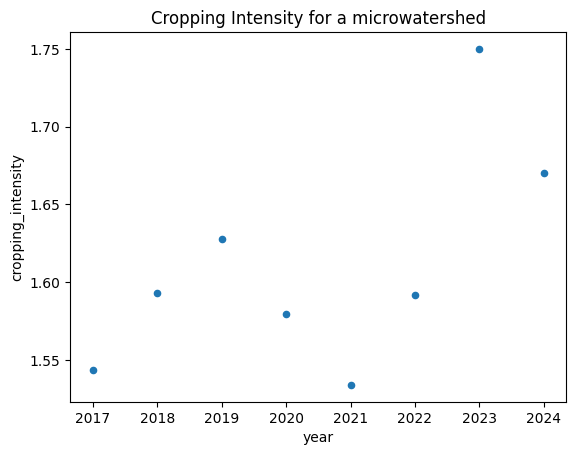

In [23]:
vector_data_mws_df.plot.scatter(x='year', y='cropping_intensity',title='Cropping Intensity for a microwatershed');

2. Loading a Vector data : Select id of the item of interest from the search result and load it

In [24]:
raster_item = catalog.get_item(id='jharkhand_dumka_masalia_land_use_land_cover_raster_2024')
# raster_item

In [ ]:
response = requests.get(raster_item.assets['data'].href)

if response.status_code == 200:
    # Use MemoryFile to treat the downloaded bytes as a file
    with rasterio.MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            print(f"CRS: {src.crs}")
            print(f"Shape: {src.shape}")
            data = src.read(1)

In [ ]:
image_plot = rasterio.plot.show(data)